# Practical 8: Data Visualization and EDA

**Objective:** Use visual tools to understand the dataset.

- Requests per hour
- Top 10 attacking IPs
- Attack categories over time
- Status code distributions
- Heatmap of top IPs vs. request types

**Tools:** Matplotlib, Seaborn

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('logs/features_access_log.csv', parse_dates=['Date/Time'])
attacks_per_ip = pd.read_csv('logs/attacks_per_ip.csv', index_col='IP Address')
hourly_by_label = pd.read_csv('logs/hourly_traffic_by_label.csv', index_col='Date/Time', parse_dates=True)
print('Data loaded.')

Data loaded.


## 1. Requests per hour

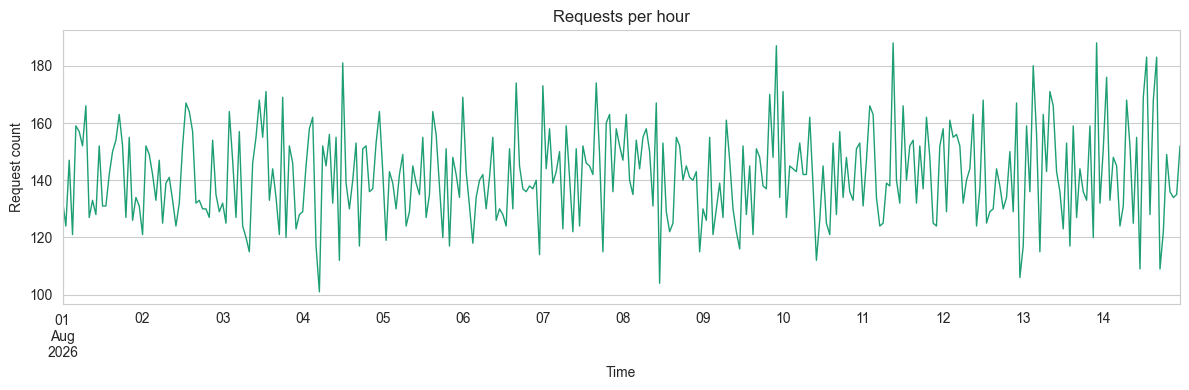

In [18]:
hourly_total = df.set_index('Date/Time').resample('h').size()

fig, ax = plt.subplots(figsize=(12, 4))
hourly_total.plot(ax=ax, color='#1D9E75', linewidth=1)
ax.set_title('Requests per hour')
ax.set_xlabel('Time')
ax.set_ylabel('Request count')
plt.tight_layout()
plt.savefig('visuals/requests_per_hour.png', dpi=100)
plt.show()

## 2. Top 10 attacking IPs

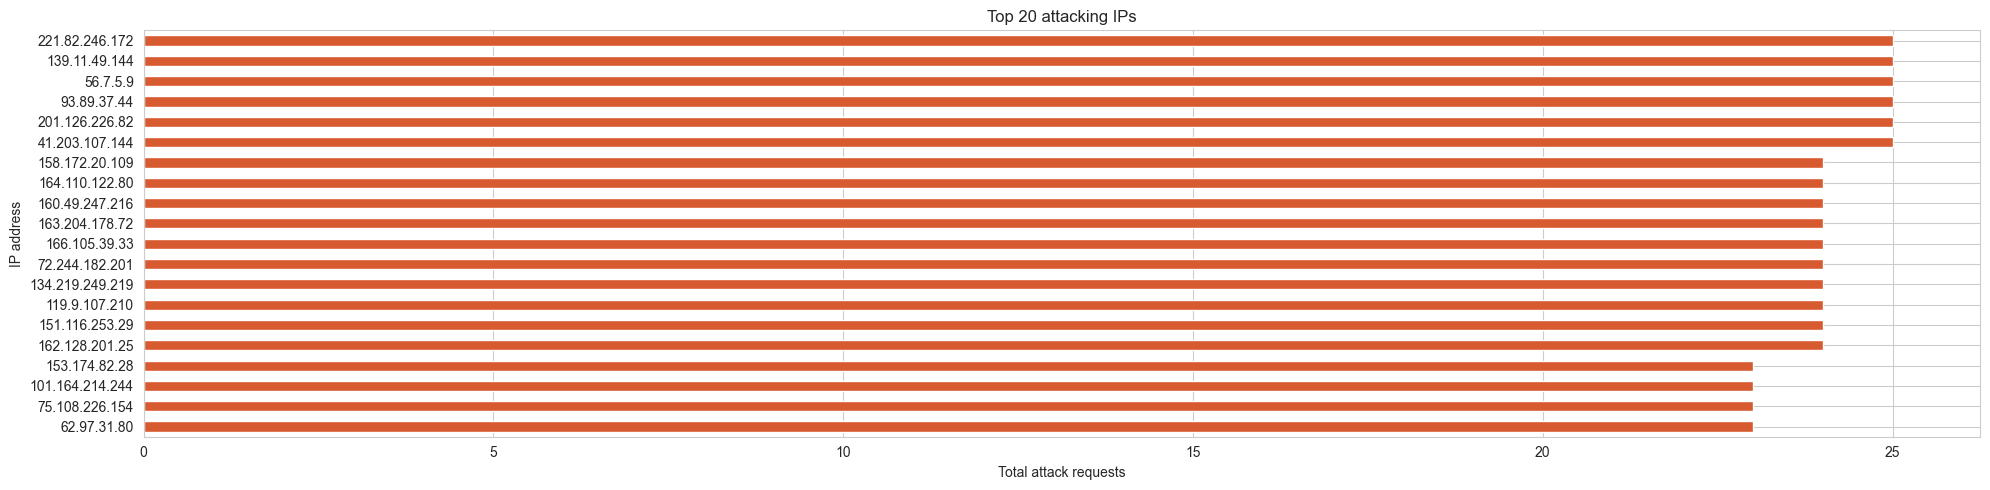

In [19]:
top20_ips = attacks_per_ip.sort_values('total_attacks', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(20, 5))
top20_ips['total_attacks'].sort_values().plot.barh(ax=ax, color='#D85A30')
ax.set_title('Top 20 attacking IPs')
ax.set_xlabel('Total attack requests')
ax.set_ylabel('IP address')
plt.tight_layout()
plt.savefig('visuals/top20_attacking_ips.png', dpi=100)
plt.show()

## 3. Attack categories over time

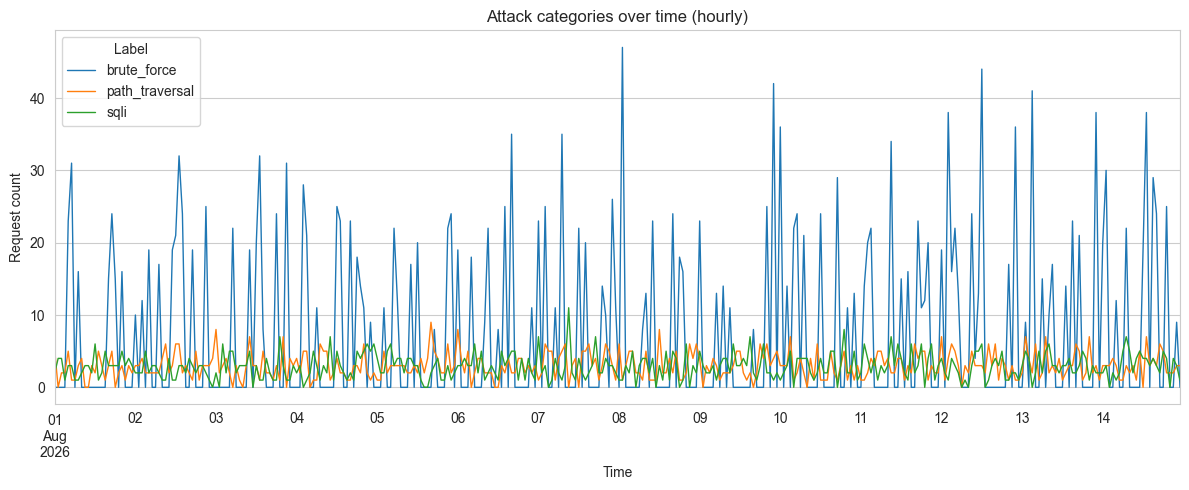

In [20]:
attack_only_labels = [c for c in hourly_by_label.columns if c != 'benign']

fig, ax = plt.subplots(figsize=(12, 5))
hourly_by_label[attack_only_labels].plot(ax=ax, linewidth=1)
ax.set_title('Attack categories over time (hourly)')
ax.set_xlabel('Time')
ax.set_ylabel('Request count')
ax.legend(title='Label')
plt.tight_layout()
plt.savefig('visuals/attack_categories_over_time.png', dpi=100)
plt.show()

## 4. Status code distribution

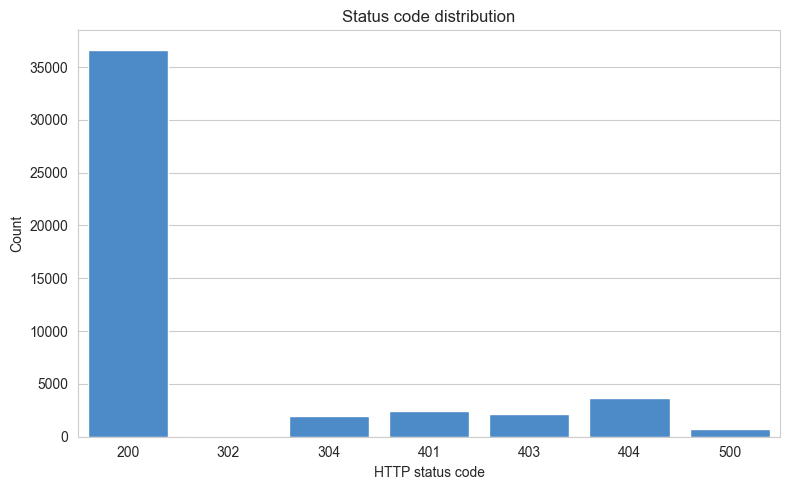

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Status Code', order=sorted(df['Status Code'].unique()),
              color='#378ADD', ax=ax)
ax.set_title('Status code distribution')
ax.set_xlabel('HTTP status code')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('visuals/status_code_distribution.png', dpi=100)
plt.show()

## 5. Heatmap: top IPs vs. label

Restricted to a representative sample of IPs, since a heatmap across all unique IPs in the dataset would be unreadable at this scale. Sampling the top 15 IPs by raw volume is not useful here: brute-force IPs dominate total request counts, so a pure top-15-by-volume sample is all brute force and every other label vanishes. Instead, the top few IPs *per label* are sampled, giving a heatmap that actually shows how different attack categories compare side by side.

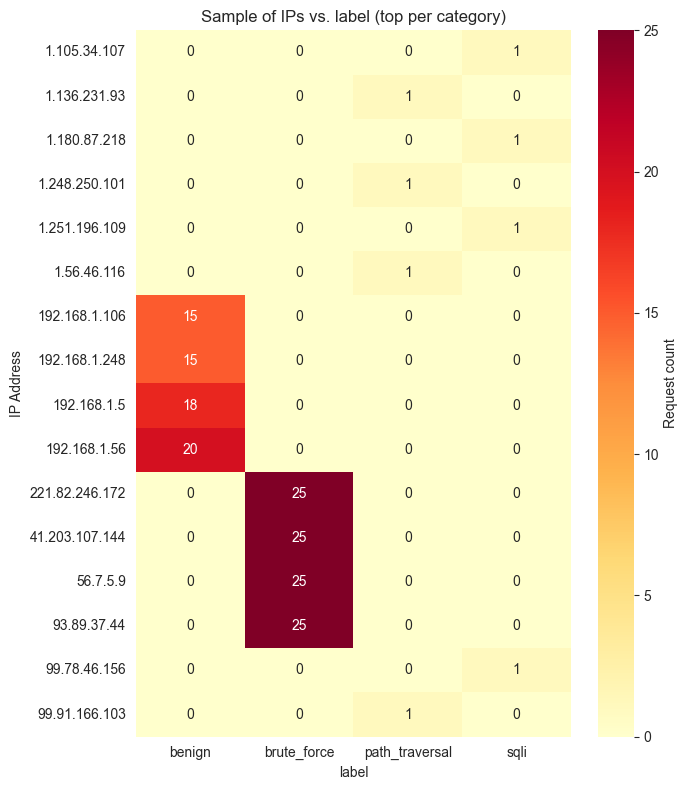

In [22]:
TOP_N_PER_LABEL = 4

sampled_ips = []
for label in df['label'].unique():
    label_ips = (
        df[df['label'] == label]['IP Address']
        .value_counts()
        .head(TOP_N_PER_LABEL)
        .index.tolist()
    )
    sampled_ips.extend(label_ips)

subset = df[df['IP Address'].isin(sampled_ips)]

pivot = pd.pivot_table(
    subset, index='IP Address', columns='label',
    values='Status Code', aggfunc='count', fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Request count'})
ax.set_title('Sample of IPs vs. label (top per category)')
plt.tight_layout()
plt.savefig('visuals/ip_label_heatmap.png', dpi=100)
plt.show()

## Observations

- Hourly request volume follows expected diurnal-style variation given the synthetic traffic generation.
- The top attacking IPs are dominated by brute-force sources, since each brute-force IP contributes many requests (8-25 login attempts), unlike SQLi/traversal IPs which typically appear once or twice.
- Status code distribution shows a concentration in the 2xx and 4xx ranges, with 4xx codes elevated relative to a purely benign baseline due to the injected attack traffic being rejected by the server.